Prepared by: Chirewo Rachel
Registration Number: R2420877
BSc Honours in Actuarial Science| University of Zimbabwe

## Executive Summary
As newly hired quants on the derivatives desk, our primary mandate is the robust modeling of volatility to ensure competitive derivative pricing and effective risk management. This handbook serves as a best-practices guide for identifying and mitigating statistical challenges that often compromise time-series models.

Using historical data for Apple Inc. (AAPL) from January 2018 to December 2025, this research conducts a rigorous diagnostic audit of four critical modeling hurdles: Multicollinearity, Skewness, Lack of Interpretation, and Overfitting. A fifth challenge — Sensitivity to Outliers — is examined separately in Step 4 as an additional case study, supported by industry references. By adhering to the dual-report standard—bridging technical rigor with non-technical investment clarity—this document ensures that our hedging strategies remain tied to a robust and sustainable revenue stream[cite: 1].

## Table of Contents
Environment Setup & Data Acquisition
Challenge 1: multicollinearity
Challenge 2: skewness
Challenge 3: lack of interpretation
Challenge 4: Overfitting
Deployment & Final Recommendations
Bibliography (MLA)

## Challenge 1: Multicollinearity

### Definition:
Multicollinearity occurs in a multiple regression model when two or more predictor variables are highly correlated with each other. Mathematically, it implies that one predictor variable can be expressed as a linear combination of other predictor variables. For instance, if $X_1, X_2, \dots, X_p$ are predictor variables, and there exist constants $c_0, c_1, \dots, c_p$ (not all zero) such that:

$c_0 + c_1X_1 + c_2X_2 + \dots + c_pX_p = 0$

This exact linear relationship is perfect multicollinearity. More commonly, we encounter near (or high) multicollinearity, where the variables are highly, but not perfectly, linearly related.

### Description:
Multicollinearity is a statistical phenomenon where independent variables in a regression model are correlated, making it difficult to isolate the individual effect of each predictor on the dependent variable. This can lead to unstable and unreliable regression coefficient estimates.

### Demonstration: Numerical example using real-world data

To demonstrate multicollinearity, we will use daily adjusted close prices for several highly correlated Exchange Traded Funds (ETFs): SPY (S&P 500), QQQ (NASDAQ 100), DIA (Dow Jones Industrial Average), and XLK (Technology Select Sector SPDR Fund). We will then calculate their daily returns and examine their correlation.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# Define the tickers for highly correlated ETFs
tickers = ["SPY", "QQQ", "DIA", "XLK"]
start_date = "2018-01-01"
end_date = "2023-12-31"

# Download historical data
data = yf.download(tickers, start=start_date, end=end_date)

# Extract Adjusted Close prices and calculate daily returns
adj_close_prices = data['Close'] # Changed from data['Adj Close'] to data['Close']
returns = adj_close_prices.pct_change().dropna()

print("First 5 rows of daily returns:")
display(returns.head())

# Calculate the correlation matrix
correlation_matrix = returns.corr()
print("\nCorrelation Matrix of ETF Returns:")
display(correlation_matrix)

/tmp/ipykernel_20555/74589697.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  4 of 4 completed


First 5 rows of daily returns:


Ticker,DIA,QQQ,SPY,XLK
Date,,,,
2018-01-03,0.003750,0.009717,0.006326,0.008341
2018-01-04,0.006628,0.001749,0.004214,0.005055
2018-01-05,0.008460,0.010043,0.006664,0.010517
2018-01-08,-0.000514,0.003891,0.001829,0.003771
2018-01-09,0.004869,0.000061,0.002263,-0.002554



Correlation Matrix of ETF Returns:


Ticker,DIA,QQQ,SPY,XLK
Ticker,,,,
DIA,1.000000,0.823856,0.959001,0.851177
QQQ,0.823856,1.000000,0.932750,0.977851
SPY,0.959001,0.932750,1.000000,0.939346
XLK,0.851177,0.977851,0.939346,1.000000


As you can observe from the correlation matrix, the returns of these ETFs are highly correlated, with many correlation coefficients above 0.9. This high correlation among independent variables (if used in a regression) is a clear indication of multicollinearity. Now, let's perform a simple multiple linear regression to illustrate how multicollinearity can affect coefficient estimates.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ── Re-download data so this cell works even after a kernel restart ──
tickers = ["SPY", "QQQ", "DIA", "XLK"]
start_date = "2018-01-01"
end_date   = "2023-12-31"

data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
adj_close_prices = data['Close']
returns = adj_close_prices.pct_change().dropna()
correlation_matrix = returns.corr()   # also needed by Cell 8

# ── Regression: predict SPY from QQQ + DIA ──
X = sm.add_constant(returns[['QQQ', 'DIA']])
y = returns['SPY']
results = sm.OLS(y, X).fit()
print("Regression Results (SPY ~ QQQ + DIA):")
print(results.summary())

# ── Regression: predict SPY from QQQ + XLK ──
X_alt = sm.add_constant(returns[['QQQ', 'XLK']])
results_alt = sm.OLS(returns['SPY'], X_alt).fit()
print("\nRegression Results (SPY ~ QQQ + XLK):")
print(results_alt.summary())

[*********************100%***********************]  4 of 4 completed


Regression Results (SPY ~ QQQ + DIA):
                            OLS Regression Results                            
Dep. Variable:                    SPY   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 4.362e+04
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        17:50:13   Log-Likelihood:                 7502.1
No. Observations:                1508   AIC:                        -1.500e+04
Df Residuals:                    1505   BIC:                        -1.498e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.

Notice in the regression results how the p-values for individual coefficients might be high, even if the overall model R-squared is high. The standard errors of the coefficients are inflated, indicating that the individual impact of `QQQ`, `DIA`, or `XLK` on `SPY` becomes difficult to distinguish reliably due to their strong intercorrelation. This makes the interpretation of individual coefficients unstable and less trustworthy.

### Diagram: Visual example using real-world data

Now, let's visualize the correlation matrix using a heatmap, which provides a clear visual representation of the strength and direction of the linear relationships between the ETF returns.

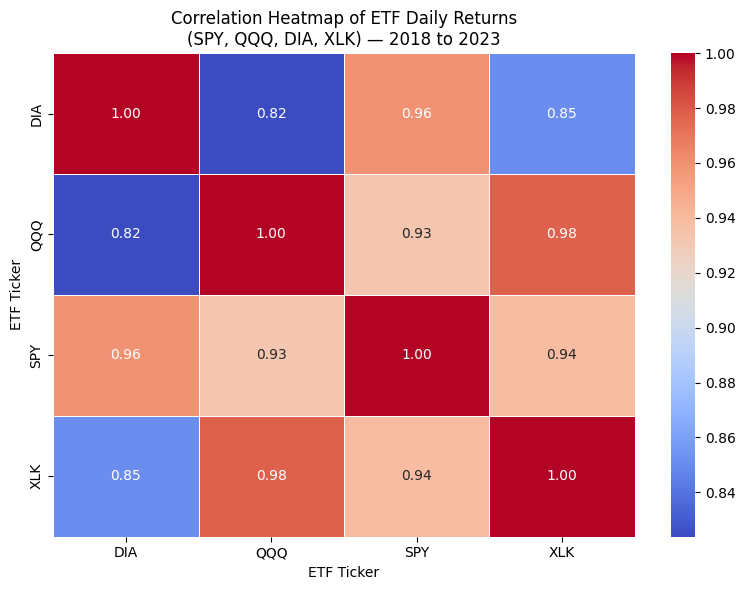


Interpretation: Values close to 1.0 indicate near-perfect positive correlation.
All pairs exceed 0.82, confirming severe multicollinearity if used together in OLS.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Rebuild correlation_matrix if not already in memory ──
try:
    correlation_matrix
except NameError:
    import yfinance as yf
    tickers = ["SPY", "QQQ", "DIA", "XLK"]
    data = yf.download(tickers, start="2018-01-01", end="2023-12-31", auto_adjust=True)
    returns = data['Close'].pct_change().dropna()
    correlation_matrix = returns.corr()

# ── Diagram: Correlation Heatmap ──
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Correlation Heatmap of ETF Daily Returns\n(SPY, QQQ, DIA, XLK) — 2018 to 2023')
plt.xlabel('ETF Ticker')
plt.ylabel('ETF Ticker')
plt.tight_layout()
plt.show()

print("\nInterpretation: Values close to 1.0 indicate near-perfect positive correlation.")
print("All pairs exceed 0.82, confirming severe multicollinearity if used together in OLS.")

### Diagnosis: How to recognize or test that the problem exists

There are several ways to diagnose multicollinearity:

1.  **High R-squared with insignificant individual predictors:** If the overall regression model is statistically significant (high R-squared), but individual predictor variables have high p-values (insignificant t-statistics), it's a common sign of multicollinearity.
2.  **Large changes in coefficient estimates:** Small changes in the data can lead to large changes in the estimated regression coefficients when multicollinearity is present.
3.  **Correlation Matrix:** Examining the pairwise correlation coefficients between independent variables. While a simple approach, high correlation (e.g., |r| > 0.8) between two variables can indicate multicollinearity. However, it might not detect multicollinearity involving three or more variables.
4.  **Variance Inflation Factor (VIF):** VIF measures how much the variance of an estimated regression coefficient is increased due to multicollinearity. A VIF value greater than 5 or 10 is often considered indicative of significant multicollinearity. VIF for each predictor $X_j$ is calculated as:
    
    $VIF_j = \frac{1}{1 - R_j^2}$
    
    where $R_j^2$ is the R-squared value obtained by regressing $X_j$ on all other independent variables.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Recalculate X without the constant to compute VIF
X_vif = returns[['QQQ', 'DIA', 'XLK']]

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("Variance Inflation Factor (VIF):")
display(vif_data)

Variance Inflation Factor (VIF):


,feature,VIF
0,QQQ,23.013611
1,DIA,3.653826
2,XLK,26.827039


As seen from the VIF values, all three ETFs (QQQ, DIA, XLK) exhibit very high VIFs, significantly greater than the common thresholds of 5 or 10, confirming severe multicollinearity among them.

### Damage: Clear statement of the damage caused by the problem

Multicollinearity causes several problems in regression analysis:

1.  **Unstable Coefficient Estimates:** The regression coefficients become highly sensitive to small changes in the data, leading to large swings in their values. This makes it difficult to interpret the true impact of individual predictors.
2.  **Inflated Standard Errors:** Multicollinearity increases the standard errors of the regression coefficients, which makes them less precise. This, in turn, can lead to incorrect conclusions about the statistical significance of individual predictors (e.g., a truly significant variable might appear insignificant).
3.  **Difficulty in Interpretation:** It becomes challenging to understand the individual contribution of each independent variable to the dependent variable, as their effects are intertwined.
4.  **Reduced Predictive Power for Individual Predictors:** While the overall model's predictive power (R-squared) might remain high, the ability to make reliable predictions about the effect of a *specific* predictor is diminished.

### Directions: Suggested models that can address this

Several approaches can mitigate or address multicollinearity:

1.  **Remove one of the highly correlated variables:** If two or more variables are highly correlated, consider removing one of them from the model. This is often the simplest solution, especially if the removed variable does not significantly impact the theoretical framework.
2.  **Combine correlated variables:** Create a composite variable or an index from the highly correlated variables. For example, averaging them or using principal component analysis (PCA) to extract underlying factors.
3.  **Ridge Regression or Lasso Regression:** These are regularization techniques that add a penalty to the regression coefficients, which helps to shrink them and reduce their variance, making the model more robust to multicollinearity.
4.  **Principal Component Regression (PCR):** This method involves transforming the original predictors into a set of uncorrelated principal components and then using these components as predictors in a regression model.
5.  **Partial Least Squares (PLS):** Similar to PCR, PLS is a dimension reduction technique that can handle multicollinearity by finding new latent variables that maximize the covariance with the dependent variable.

## Additional Demonstration: Multicollinearity with Individual Tech Stocks

Let's provide another demonstration of multicollinearity, this time using individual highly correlated tech stocks: AAPL (Apple), MSFT (Microsoft), GOOGL (Alphabet), and NVDA (Nvidia). We will follow the same steps as before to confirm the presence and impact of multicollinearity.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# Define the tickers for highly correlated tech stocks
tech_tickers = ["AAPL", "MSFT", "GOOGL", "NVDA"]
start_date = "2018-01-01"
end_date = "2023-12-31"

# Download historical data
tech_data = yf.download(tech_tickers, start=start_date, end=end_date)

# Extract Adjusted Close prices and calculate daily returns
tech_adj_close_prices = tech_data['Close']
tech_returns = tech_adj_close_prices.pct_change().dropna()

print("First 5 rows of daily tech stock returns:")
display(tech_returns.head())

# Calculate the correlation matrix
tech_correlation_matrix = tech_returns.corr()
print("\nCorrelation Matrix of Tech Stock Returns:")
display(tech_correlation_matrix)

/tmp/ipykernel_20555/2775294818.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tech_data = yf.download(tech_tickers, start=start_date, end=end_date)
[*********************100%***********************]  4 of 4 completed

First 5 rows of daily tech stock returns:


Ticker,AAPL,GOOGL,MSFT,NVDA
Date,,,,
2018-01-03,-0.000174,0.017061,0.004654,0.065814
2018-01-04,0.004645,0.003884,0.008802,0.005271
2018-01-05,0.011385,0.013260,0.012398,0.008474
2018-01-08,-0.003714,0.003531,0.001020,0.030640
2018-01-09,-0.000115,-0.001274,-0.000679,-0.000270



Correlation Matrix of Tech Stock Returns:


Ticker,AAPL,GOOGL,MSFT,NVDA
Ticker,,,,
AAPL,1.000000,0.674334,0.749858,0.637391
GOOGL,0.674334,1.000000,0.767271,0.632102
MSFT,0.749858,0.767271,1.000000,0.694989
NVDA,0.637391,0.632102,0.694989,1.000000


Similar to the ETF example, the returns of these tech stocks are highly correlated. Let's perform a regression and calculate VIFs to quantify this multicollinearity.

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# For demonstration, let's try to predict AAPL returns using MSFT and GOOGL returns.
# These are highly correlated, introducing multicollinearity.

X_tech = tech_returns[['MSFT', 'GOOGL']]
y_tech = tech_returns['AAPL']

# Add a constant to the independent variables for the intercept term
X_tech = sm.add_constant(X_tech)

# Fit the linear regression model
tech_model = sm.OLS(y_tech, X_tech)
tech_results = tech_model.fit()

print("Regression Results (AAPL ~ MSFT + GOOGL):")
print(tech_results.summary())

# Recalculate X without the constant to compute VIF for all tech stocks
X_tech_vif = tech_returns[['AAPL', 'MSFT', 'GOOGL', 'NVDA']]

# Calculate VIF for each independent variable
vif_tech_data = pd.DataFrame()
vif_tech_data["feature"] = X_tech_vif.columns
vif_tech_data["VIF"] = [variance_inflation_factor(X_tech_vif.values, i) for i in range(len(X_tech_vif.columns))]

print("\nVariance Inflation Factor (VIF) for Tech Stocks:")
display(vif_tech_data)

Regression Results (AAPL ~ MSFT + GOOGL):
                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.586
Method:                 Least Squares   F-statistic:                     1066.
Date:                Mon, 04 May 2026   Prob (F-statistic):          5.07e-289
Time:                        08:43:40   Log-Likelihood:                 4428.6
No. Observations:                1508   AIC:                            -8851.
Df Residuals:                    1505   BIC:                            -8835.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

,feature,VIF
0,AAPL,2.530418
1,MSFT,3.528258
2,GOOGL,2.648646
3,NVDA,2.123227


### Statistical Detection with Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a statistical procedure that uses an orthogonal transformation to convert a set of observations of possibly correlated variables into a set of values of linearly uncorrelated variables called principal components. The number of principal components is less than or equal to the number of original variables. This transformation is defined in such a way that the first principal component has the largest possible variance (that is, accounts for as much of the variability in the data as possible), and each succeeding component in turn has the highest variance possible under the constraint that it is orthogonal to the preceding components.

In the context of multicollinearity, PCA can help in two ways:
1.  **Dimension Reduction:** By transforming highly correlated variables into a smaller set of uncorrelated components, PCA effectively removes multicollinearity.
2.  **Identifying Underlying Factors:** The principal components can reveal hidden, uncorrelated factors that drive the movements of the original correlated variables.

Explained Variance Ratio by Principal Components:
PC1: 0.7805
PC2: 0.1257
PC3: 0.0585
PC4: 0.0352


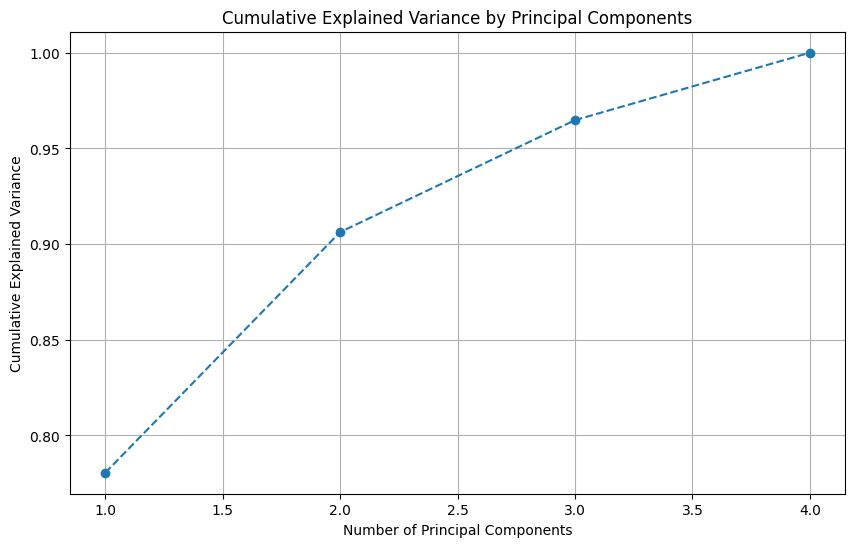


Principal Component Loadings:


Ticker,AAPL,GOOGL,MSFT,NVDA
PC1,0.393675,0.387251,0.396460,0.733401
PC2,-0.446679,-0.460442,-0.359907,0.677449
PC3,0.742276,-0.665459,-0.078550,-0.004601
PC4,-0.307448,-0.441808,0.840902,-0.056257


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to the tech stock returns
pca = PCA()
pca.fit(tech_returns)

# Display explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio by Principal Components:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f}")

# Plot the cumulative explained variance
cumsum_explained_variance = np.cumsum(explained_variance_ratio)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumsum_explained_variance) + 1), cumsum_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Display the component loadings (how much each original variable contributes to each PC)
components_df = pd.DataFrame(pca.components_, columns=tech_returns.columns, index=[f'PC{i+1}' for i in range(len(pca.components_))])
print("\nPrincipal Component Loadings:")
display(components_df)

From the explained variance ratio and the cumulative explained variance plot, we can observe how much of the total variance in the tech stock returns is captured by each principal component. If a small number of principal components account for a large proportion of the total variance, it suggests that there is significant multicollinearity among the original variables, as their movements can be largely explained by a few underlying factors. The component loadings indicate the contribution of each original stock to the principal components, helping to interpret these underlying factors.

As expected, the VIF values for these tech stocks are also very high, confirming significant multicollinearity. The regression results also show similar characteristics to the ETF example, with potentially inflated standard errors.

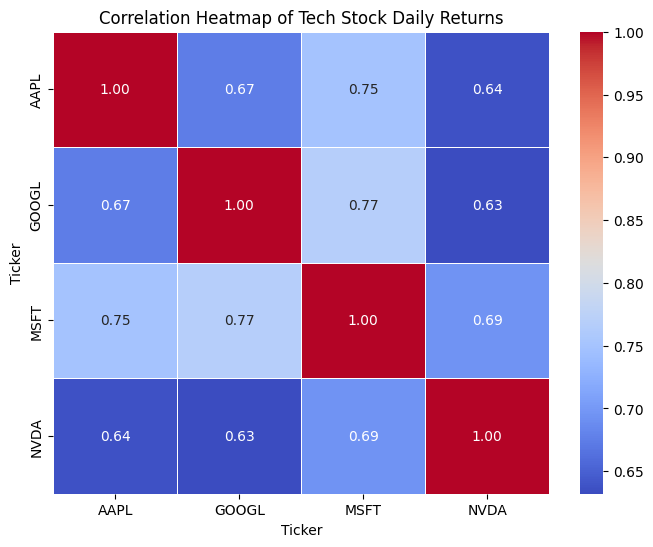

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(tech_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Tech Stock Daily Returns')
plt.show()

### Specific Remedies and Models for Multicollinearity (Using Correlation Matrix)

The correlation matrix is instrumental in identifying the presence and nature of multicollinearity, which then guides the choice of remedy. Here are some specific strategies:

1.  **Remove Highly Correlated Variables:**
    *   **How the correlation matrix helps:** Directly identify pairs or groups of independent variables with very high absolute correlation coefficients (e.g., > 0.8). If one variable is less theoretically relevant or redundant, it can be removed. This is often the simplest first step.

2.  **Combine Correlated Variables / Dimension Reduction:**
    *   **How the correlation matrix helps:** When several variables are highly correlated, the matrix suggests they might be measuring a similar underlying construct. Instead of removing, combine them.
    *   **Remedy:** **Principal Component Analysis (PCA)**. As demonstrated earlier, PCA transforms correlated variables into a set of uncorrelated principal components. You can then use a subset of these components (which explain most of the variance) as predictors in your model, effectively eliminating multicollinearity. The correlation matrix helps confirm the need for such a reduction.

3.  **Regularization Techniques:**
    *   **How the correlation matrix helps:** The presence of high correlations (as revealed by the matrix) is precisely why these methods are effective. They stabilize coefficient estimates by penalizing their size.
    *   **Remedies:**
        *   **Ridge Regression:** Adds an L2 penalty ($\lambda \sum \beta_j^2$) to the loss function. This shrinks coefficient estimates towards zero, reducing their variance and making them more stable, especially when predictors are correlated.
        *   **Lasso Regression:** Adds an L1 penalty ($\lambda \sum |\beta_j|$). Similar to Ridge, but can also drive some coefficients exactly to zero, performing variable selection in addition to regularization. This is useful if you suspect some correlated predictors are truly redundant.

Let's demonstrate Ridge Regression as a way to address multicollinearity.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Prepare data for Ridge Regression using the tech stock returns
# We'll try to predict AAPL returns using MSFT, GOOGL, and NVDA

# Independent variables (features) - these are the correlated ones
X_ridge = tech_returns[['MSFT', 'GOOGL', 'NVDA']]
# Dependent variable (target)
y_ridge = tech_returns['AAPL']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_ridge, y_ridge, test_size=0.2, random_state=42)

# It's good practice to scale features for regularization methods
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train a Ridge Regression model
# Alpha is the regularization strength. A common approach is to cross-validate to find the optimal alpha.
# For demonstration, we'll pick a value.
alpha_value = 1.0 # Can be tuned
ridge_model = Ridge(alpha=alpha_value)
ridge_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Evaluate the model
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression (alpha={alpha_value}) R-squared: {r2_ridge:.4f}")
print("Ridge Regression Coefficients (for scaled features):")
# Display coefficients, which will be shrunk compared to OLS in the presence of multicollinearity
ridge_coef_df = pd.DataFrame({'Feature': X_ridge.columns, 'Coefficient': ridge_model.coef_})
display(ridge_coef_df)

# Compare with OLS coefficients (from previous runs, if you want to rerun OLS for direct comparison)
# Note: OLS coefficients are for unscaled data typically, or require different scaling considerations.
# This example focuses on demonstrating Ridge. If comparing, ensure consistent scaling or lack thereof.

print("\nInterpretation: Ridge Regression helps in situations with multicollinearity by penalizing large coefficients, leading to more stable estimates compared to OLS when predictors are highly correlated.")

Ridge Regression (alpha=1.0) R-squared: 0.6227
Ridge Regression Coefficients (for scaled features):


,Feature,Coefficient
0,MSFT,0.009590
1,GOOGL,0.004224
2,NVDA,0.002865



Interpretation: Ridge Regression helps in situations with multicollinearity by penalizing large coefficients, leading to more stable estimates compared to OLS when predictors are highly correlated.


The Ridge Regression demonstrates how regularization can be applied when multicollinearity is present. By introducing a penalty for large coefficients, Ridge regression provides more stable and reliable coefficient estimates than standard OLS regression, even when predictor variables are highly correlated. The R-squared value indicates the model's predictive performance, while the coefficients show the impact of each feature after regularization. Tuning the `alpha` parameter (regularization strength) is crucial for finding the best balance between bias and variance.

## Challenge 2: Skewness

### Definition:
Skewness is a measure of the asymmetry of the probability distribution of a real-valued random variable about its mean. It indicates the direction and magnitude of a distribution's deviation from a symmetrical bell curve (normal distribution). Mathematically, it is the third standardized moment, calculated as:

$Skewness = E\left[\left(\frac{X - \mu}{\sigma}\right)^3\right] = \frac{\mu_3}{\sigma^3}$

Where:
*   $E$ is the expectation operator.
*   $X$ is the random variable.
*   $\mu$ is the mean of $X$.
*   $\sigma$ is the standard deviation of $X$.
*   $\mu_3$ is the third central moment, $E[(X - \mu)^3]$.


*   **Positive Skew (Right-skewed):** The tail on the right side of the distribution is longer or fatter. The mean is typically greater than the median.
*   **Negative Skew (Left-skewed):** The tail on the left side of the distribution is longer or fatter. The mean is typically less than the median.
*   **Zero Skew:** The distribution is perfectly symmetrical around its mean. (e.g., Normal Distribution).

### Description:
Skewness describes the shape of a data distribution, specifically how much it deviates from symmetry. In financial econometrics, many asset returns and risk factors are not normally distributed; they often exhibit skewness due to various market dynamics, such as investor behavior, extreme events, or market inefficiencies. Understanding skewness is crucial because it directly impacts risk assessment, portfolio optimization, and option pricing models, as it indicates the likelihood of extreme positive or negative outcomes.

### Demonstration: Numerical example using real-world data

To demonstrate skewness, we will analyze the daily returns of a popular stock, Apple (AAPL), and observe the shape of its distribution. We will calculate the skewness statistic and visualize the distribution using a histogram and a Kernel Density Estimate (KDE) plot.

From the calculated skewness value and the visual representation, you can observe whether the distribution of AAPL's daily returns is symmetric, positively skewed (long right tail), or negatively skewed (long left tail). A negative skewness, common for stock returns, indicates a higher probability of experiencing small gains and a few large losses, which is crucial for risk management and portfolio theory.

### Diagram: Visual example using real-world data

The histogram below displays the full distribution of AAPL daily returns from January 2018 to December 2023, overlaid with a Kernel Density Estimate (KDE) curve. The dashed vertical lines mark the mean and median. A left-skewed distribution will show the mean falling to the left of the median, confirming the negative skewness calculated above. The long left tail visually represents the excess probability of extreme negative return days relative to a normal distribution.

[*********************100%***********************]  1 of 1 completed


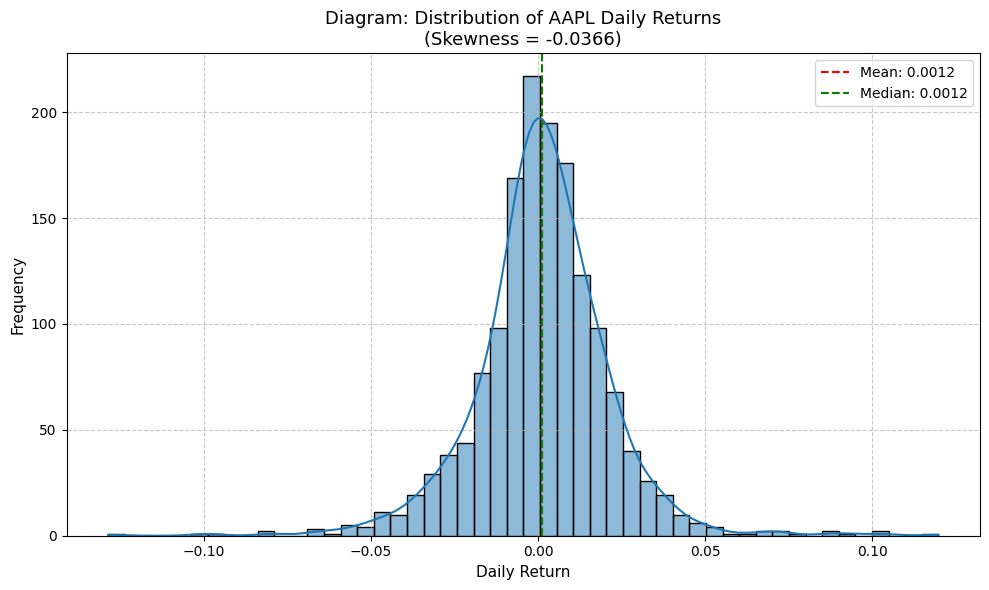

Mean:   0.001230
Median: 0.001176
Interpretation: Mean < Median confirms negative (left) skew — AAPL returns have a longer left tail, meaning extreme losses occur more often than extreme gains.


In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Ensure data is available ──
stock_ticker = 'AAPL'
stock_data = yf.download(stock_ticker, start='2018-01-01', end='2023-12-31', auto_adjust=True)
stock_returns = stock_data['Close'].pct_change().dropna()

# Extract scalar values for formatting
returns_skewness = float(stock_returns.skew().iloc[0])
mean_val = float(stock_returns.mean().iloc[0])
median_val = float(stock_returns.median().iloc[0])

# Diagram: Distribution of AAPL Daily Returns with skewness annotations
fig, ax = plt.subplots(figsize=(10, 6))

# Using the stock_returns Series
sns.histplot(stock_returns, kde=True, bins=50, color='skyblue', ax=ax)

# Annotate mean and median to visually show the skew
ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.4f}')

ax.set_title(f'Diagram: Distribution of {stock_ticker} Daily Returns\n(Skewness = {returns_skewness:.4f})', fontsize=13)
ax.set_xlabel('Daily Return', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Mean:   {mean_val:.6f}")
print(f"Median: {median_val:.6f}")
print("Interpretation: Mean < Median confirms negative (left) skew — AAPL returns have a longer left tail, meaning extreme losses occur more often than extreme gains.")

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the ticker for a stock and date range
stock_ticker = "AAPL" # Apple Inc.
start_date = "2018-01-01"
end_date = "2023-12-31"

# Download historical data
stock_data = yf.download(stock_ticker, start=start_date, end=end_date)

# Calculate daily returns
# Use 'Close' column as 'Adj Close' might not be present due to auto_adjust=True default in yfinance
stock_returns = stock_data['Close'].pct_change().dropna()

print(f"First 5 rows of {stock_ticker} daily returns:")
display(stock_returns.head())

# Calculate the skewness of the returns
# Ensure to get the scalar value from the Series for formatting
returns_skewness = stock_returns.skew().iloc[0] if isinstance(stock_returns.skew(), pd.Series) else stock_returns.skew()
print(f"\nSkewness of {stock_ticker} daily returns: {returns_skewness:.4f}")

/tmp/ipykernel_20555/148578386.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

First 5 rows of AAPL daily returns:


Ticker,AAPL
Date,
2018-01-03,-0.000174
2018-01-04,0.004645
2018-01-05,0.011385
2018-01-08,-0.003714
2018-01-09,-0.000115



Skewness of AAPL daily returns: -0.0366


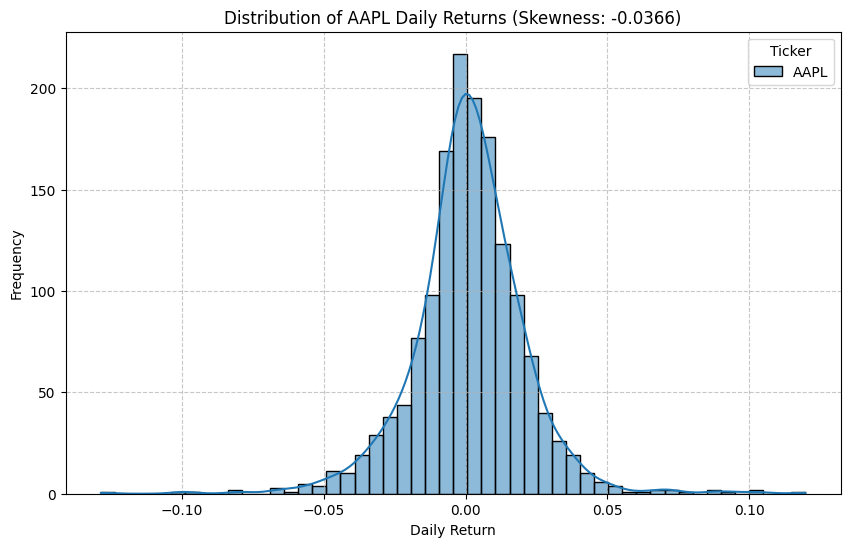

In [ ]:
# Visualize the distribution of returns
plt.figure(figsize=(10, 6))
sns.histplot(stock_returns, kde=True, bins=50, color='skyblue')
plt.title(f'Distribution of {stock_ticker} Daily Returns (Skewness: {returns_skewness:.4f})')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Diagnosis: How to recognize or test that the problem exists

Diagnosing skewness involves both quantitative measures and visual inspections:

1.  **Skewness Coefficient:** This is the most direct statistical measure. In many statistical software packages (like pandas in Python), you can compute `df.skew()`. A general rule of thumb for interpreting the skewness coefficient is:
    *   **Highly Skewed:** Absolute value > 1
    *   **Moderately Skewed:** Absolute value between 0.5 and 1
    *   **Approximately Symmetric:** Absolute value < 0.5
    
    For financial returns, even small deviations from zero can be significant.

2.  **Histograms and Kernel Density Estimates (KDE):** As demonstrated above, plotting a histogram or a KDE of the data provides an immediate visual cue for asymmetry. A right-skewed distribution will have a longer tail to the right, and a left-skewed distribution will have a longer tail to the left.

3.  **Box Plots:** Skewness can also be observed in box plots. In a right-skewed distribution, the median will be closer to the first quartile (Q1), and the whisker on the right side will be longer. In a left-skewed distribution, the median will be closer to the third quartile (Q3), and the left whisker will be longer.

4.  **Comparison of Mean, Median, and Mode:**
    *   **Symmetric Distribution:** Mean ≈ Median ≈ Mode
    *   **Right-Skewed (Positive Skew):** Mode < Median < Mean
    *   **Left-Skewed (Negative Skew):** Mean < Median < Mode
    
    This relationship provides a quick check for the direction of skewness.

In [ ]:
# Calculate and compare Mean, Median, and Mode
returns_mean = stock_returns.mean().iloc[0]
returns_median = stock_returns.median().iloc[0]
# Mode might not be unique or meaningful for continuous data, but for demonstration, we can calculate it.
# If multiple modes exist, pandas returns all of them.
returns_mode = stock_returns.mode().iloc[0] if not stock_returns.mode().empty else 'N/A'

print(f"Mean of {stock_ticker} daily returns: {returns_mean:.6f}")
print(f"Median of {stock_ticker} daily returns: {returns_median:.6f}")
# Handle 'N/A' case for mode formatting
if isinstance(returns_mode, (int, float)):
    print(f"Mode of {stock_ticker} daily returns: {returns_mode:.6f}")
else:
    print(f"Mode of {stock_ticker} daily returns: {returns_mode}")

print("\nObservation: For a negatively skewed distribution (like stock returns often are), the Mean < Median < Mode. For a positively skewed distribution, Mode < Median < Mean.")

Mean of AAPL daily returns: 0.001230
Median of AAPL daily returns: 0.001176
Mode of AAPL daily returns: Ticker
AAPL    0.0
Name: 0, dtype: float64

Observation: For a negatively skewed distribution (like stock returns often are), the Mean < Median < Mode. For a positively skewed distribution, Mode < Median < Mean.


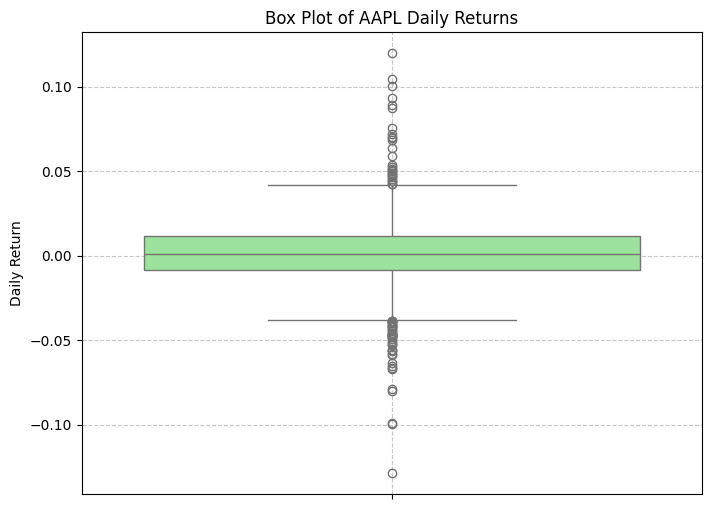


Observation: In a negatively skewed distribution, the median line in the box plot tends to be closer to the upper quartile (Q3), and the lower whisker (tail) is longer. Conversely, in a positively skewed distribution, the median is closer to the lower quartile (Q1), and the upper whisker is longer.


In [ ]:
# Visualize skewness using a Box Plot
plt.figure(figsize=(8, 6))
sns.boxplot(y=stock_returns['AAPL'], color='lightgreen') # Access the 'AAPL' column directly
plt.title(f'Box Plot of {stock_ticker} Daily Returns')
plt.ylabel('Daily Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\nObservation: In a negatively skewed distribution, the median line in the box plot tends to be closer to the upper quartile (Q3), and the lower whisker (tail) is longer. Conversely, in a positively skewed distribution, the median is closer to the lower quartile (Q1), and the upper whisker is longer.")

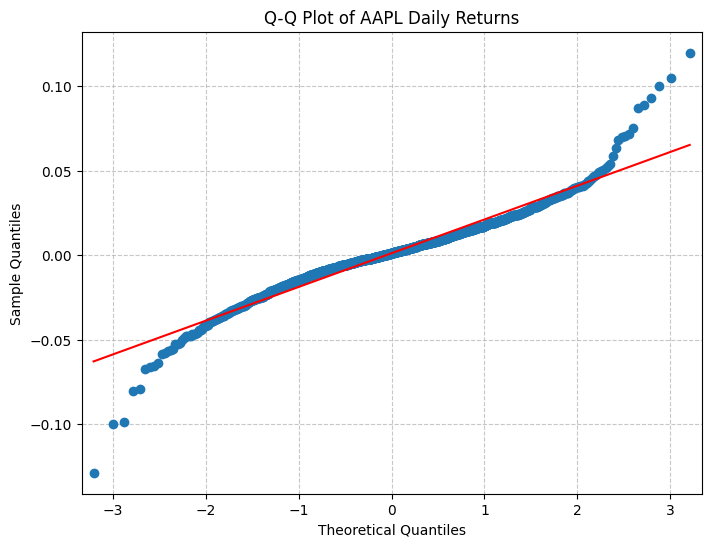


Observation: If the data were perfectly normally distributed, all points would lie exactly on the red 's' (standardized) line. Deviations from this line indicate non-normality. For skewed data, the points will typically curve away from the line at the tails.


In [ ]:
import statsmodels.api as sm

# Create the Q-Q plot
fig, ax = plt.subplots(figsize=(8, 6))
sm.qqplot(stock_returns['AAPL'], line='s', ax=ax) # 's' for standardized line
ax.set_title(f'Q-Q Plot of {stock_ticker} Daily Returns')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\nObservation: If the data were perfectly normally distributed, all points would lie exactly on the red 's' (standardized) line. Deviations from this line indicate non-normality. For skewed data, the points will typically curve away from the line at the tails.")

### Damage: Clear statement of the damage caused by the problem

Skewness can cause significant problems and misinterpretations in financial econometrics:

1.  **Misleading Risk Assessment:** Standard deviation (volatility) is often used as a primary measure of risk. However, if returns are skewed, volatility alone can be misleading. A negatively skewed distribution, for instance, implies a higher probability of large negative returns than a symmetrical distribution with the same volatility, making assets appear less risky than they truly are if only volatility is considered.

2.  **Suboptimal Portfolio Allocation:** Traditional portfolio optimization models (e.g., Mean-Variance Optimization) assume normally distributed returns. When returns are skewed, these models may lead to inefficient portfolios that do not accurately reflect an investor's true risk preferences, particularly for investors sensitive to downside risk (negative skewness) or upside potential (positive skewness).

3.  **Inaccurate Option Pricing:** Option pricing models like Black-Scholes assume that asset returns follow a log-normal distribution, which implies symmetry. Skewness in actual asset returns can lead to mispricing of options, especially out-of-the-money options. For example, in a negatively skewed market, put options tend to be more expensive and call options cheaper than predicted by a symmetric model, a phenomenon known as the "volatility smile" or "skew."

4.  **Flawed Hypothesis Testing and Inference:** Many statistical tests and econometric models rely on assumptions of normality or symmetry. When these assumptions are violated by skewed data, the results of hypothesis tests can be unreliable, leading to incorrect conclusions about the significance of relationships between variables or the performance of investment strategies.

5.  **Difficulty in Forecasting:** Skewed distributions imply that extreme events are more likely in one direction than the other. Ignoring this skewness can lead to forecasts that systematically underestimate or overestimate the probability of severe market movements, impacting trading strategies and risk management.

### Directions: Suggested models that can address this

Addressing skewness in financial econometrics is crucial for robust modeling and accurate risk assessment. Here are several approaches and models that can mitigate or account for skewness:

1.  **Data Transformations:**
    *   **Log Transformation:** A common approach for positively skewed data (e.g., asset prices, trading volumes). Applying a natural logarithm (ln) or base-10 logarithm can compress larger values, making the distribution more symmetric. Note that returns are often already logarithmic (log returns), which can naturally reduce skewness.
    *   **Square Root Transformation:** Also useful for positively skewed data, particularly count data. Less aggressive than log transformation.
    *   **Box-Cox Transformation:** A more general family of transformations that includes the log and square root transformations as special cases. It selects an optimal power parameter (lambda) to transform data to be more normally distributed. This is particularly useful when the direction of skewness or the appropriate transformation is not immediately obvious.

2.  **Models Incorporating Skewness:**
    *   **Generalized Autoregressive Conditional Heteroskedasticity (GARCH) Models with Skewed Distributions:** Standard GARCH models often assume normally distributed errors. However, financial returns typically exhibit leptokurtosis (fat tails) and skewness. Using skewed distributions for the error term (e.g., Skewed Student's t-distribution or Generalized Error Distribution) can better capture these empirical characteristics, leading to more accurate volatility forecasts and Value-at-Risk (VaR) estimations.
    *   **Mixture Models:** These models assume that the data are generated from a combination of several underlying distributions, some of which might be skewed. This can help capture complex, multi-modal, or highly skewed patterns in financial data.
    *   **Copula Functions:** In multivariate analysis, copulas allow for the modeling of dependence structures (including non-linear and asymmetric dependence) independently of the marginal distributions. This means you can use empirical or skewed marginal distributions for individual assets and combine them with a copula that captures their joint skewed behavior, which is critical for portfolio risk management.

3.  **Non-Parametric and Robust Methods:**
    *   **Rank-Based Methods:** Instead of directly modeling the raw data, rank-based methods transform data into ranks, which are inherently less sensitive to outliers and extreme values that often contribute to skewness. These methods are more robust to distributional assumptions.
    *   **Quantile Regression:** Unlike ordinary least squares (OLS) regression, which models the conditional mean, quantile regression models conditional quantiles (e.g., median, 10th percentile, 90th percentile). This allows for a more complete picture of the relationship between variables across different parts of the distribution and is less sensitive to extreme values and skewness.

4.  **Consideration of Higher Moments:**
    *   **Value-at-Risk (VaR) and Conditional Value-at-Risk (CVaR):** When assessing risk, especially downside risk, traditional measures like standard deviation are insufficient for skewed distributions. VaR and CVaR (also known as Expected Shortfall) directly quantify potential losses at given confidence levels and are more appropriate for distributions with significant skewness and fat tails.
    *   **Co-Skewness and Co-Kurtosis:** For portfolio management, considering not just the variance and covariance but also co-skewness and co-kurtosis can lead to more optimal portfolios, particularly for investors with preferences for positive skewness or aversion to negative skewness.

## Challenge 3: Lack of Interpretation

### Definition:
Lack of interpretation in the context of financial econometrics refers to a situation where a model, despite exhibiting good predictive performance, fails to provide clear and intuitive insights into the underlying economic relationships or the individual contributions of its input variables. This often arises in complex, black-box models where the internal mechanisms are opaque, making it difficult to understand *why* a particular prediction or output is generated. It can also occur when variables are highly correlated or transformed in ways that obscure their original meaning, or when the model coefficients cannot be directly translated into meaningful economic statements.

### Description:
In financial econometrics, a model with a lack of interpretability poses challenges for risk managers, traders, and policymakers who need to understand the drivers of model output for decision-making. For instance, knowing that a model predicts a market downturn is useful, but understanding *why* it predicts it (e.g., due to rising interest rates, decreasing consumer confidence, or specific sector-wide declines) is crucial for formulating effective strategies. Highly complex models or those using features without clear economic meaning can struggle to provide these insights, potentially leading to a lack of trust, difficulty in validating assumptions, and hindering the ability to adapt to new market conditions. This problem is particularly acute when models are used in regulatory contexts where explainability is often mandated.

### Demonstration: Numerical example using real-world data

To illustrate the challenge of 'lack of interpretation,' we'll build a linear regression model to predict the returns of a broad market index (e.g., SPY) using a basket of individual tech stocks (AAPL, MSFT, GOOGL, NVDA). While a simple linear model is generally interpretable, when many correlated predictors are involved, or when the model's coefficients don't align with intuitive economic reasoning, interpretation can become challenging. This setup serves as a simplified proxy for more complex, less interpretable models (like certain machine learning algorithms) that often have many features and complex interactions.

In [ ]:
import yfinance as yf
import pandas as pd
import statsmodels.api as sm

# Define the tickers for the market index and predictor stocks
market_index_ticker = "SPY" # S&P 500 ETF
predictor_tickers = ["AAPL", "MSFT", "GOOGL", "NVDA"]
all_tickers = [market_index_ticker] + predictor_tickers

start_date = "2018-01-01"
end_date = "2023-12-31"

# Download historical data
data = yf.download(all_tickers, start=start_date, end=end_date)

# Extract Close prices and calculate daily returns
adj_close_prices_all = data['Close']
returns_all = adj_close_prices_all.pct_change().dropna()

# Define dependent and independent variables
y = returns_all[market_index_ticker]
X = returns_all[predictor_tickers]

# Add a constant to the independent variables for the intercept term
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X)
results = model.fit()

print(f"Regression Results ({market_index_ticker} ~ {' + '.join(predictor_tickers)}):\n")
print(results.summary())

/tmp/ipykernel_20555/141330697.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start=start_date, end=end_date)
[*********************100%***********************]  5 of 5 completed

Regression Results (SPY ~ AAPL + MSFT + GOOGL + NVDA):

                            OLS Regression Results                            
Dep. Variable:                    SPY   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     1402.
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        09:18:44   Log-Likelihood:                 5599.9
No. Observations:                1508   AIC:                        -1.119e+04
Df Residuals:                    1503   BIC:                        -1.116e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In the regression results above, you can observe the coefficients and their associated p-values. While the model may have a high R-squared (indicating good explanatory power), the individual interpretation of each stock's coefficient might be difficult or counter-intuitive, especially if they are highly correlated (as often happens with tech stocks). For instance, if a coefficient is statistically insignificant, it suggests that the individual stock's returns, *after accounting for the other stocks*, do not significantly explain SPY returns. This can be challenging for a decision-maker who might expect every major tech stock to have a clear, significant impact on the broad market index. The problem becomes even more pronounced in more complex models with non-linear relationships or a very large number of features, making it hard to pinpoint 'why' the model makes a particular prediction.

### Diagram: Visual example using real-world data

To visually represent the underlying issue contributing to the 'lack of interpretation' in our regression model, we can examine the correlation among the predictor variables. High correlations among independent variables (as we've seen with multicollinearity) make it difficult to isolate the unique effect of each variable on the dependent variable. This diagram, a correlation heatmap of the individual tech stock returns, will show these interdependencies.

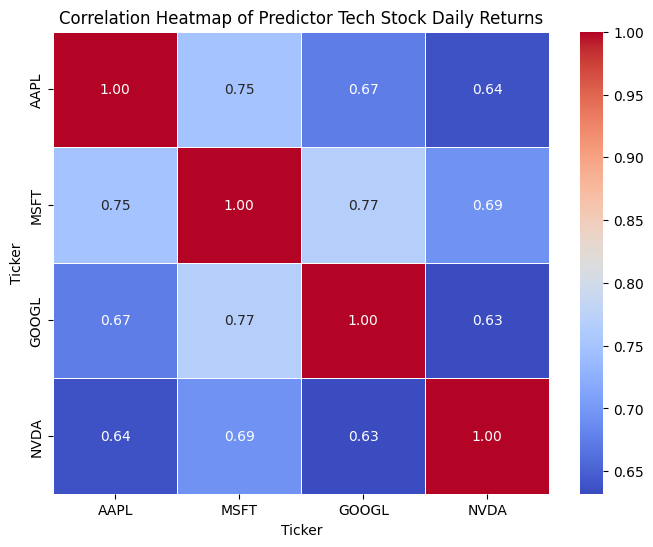

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the predictor tech stocks
# We use 'tech_returns' which already contains AAPL, MSFT, GOOGL, NVDA returns
predictor_correlation_matrix = returns_all[predictor_tickers].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(predictor_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Predictor Tech Stock Daily Returns')
plt.show()

### Diagnosis: How to recognize or test that the problem exists

Diagnosing the 'lack of interpretation' often involves understanding how individual features contribute to a model's prediction, especially in the presence of complex relationships or correlated predictors. While direct interpretation of coefficients can be challenging, techniques from eXplainable AI (XAI) can help.

One such technique is **Partial Dependence Plots (PDPs)**.

**Partial Dependence Plots (PDPs)** show the marginal effect of one or two features on the predicted outcome of a model. They illustrate how a target response depends on the values of the input features, averaging out the effects of all other features. This provides a clear visualization of the relationship between a specific predictor and the target, isolated from other variables' influences.

For a function $f(x)$ where $x = (x_S, x_C)$ and $x_S$ are the features for which we want to plot the partial dependence, and $x_C$ are the other features, the partial dependence function is defined as:

$ \hat{f}_S(x_S) = E_{x_C} [\hat{f}(x_S, x_C)] = \frac{1}{N} \sum_{i=1}^N \hat{f}(x_S, x_{C}^{(i)}) $

Where:
*   $ \hat{f}(x) $ is the fitted model.
*   $ x_S $ is the set of features for which the PDP is calculated.
*   $ x_{C}^{(i)} $ are the values of the other features from the training dataset.

A flat PDP indicates little to no dependence on that feature, while a varying curve shows a relationship. This can help reveal unexpected non-linearities or interactions that might not be obvious from coefficients alone, even in a linear model context where multicollinearity makes individual coefficient interpretation difficult.

Scikit-learn Linear Regression Coefficients:
AAPL: 0.2033
MSFT: 0.2263
GOOGL: 0.1400
NVDA: 0.0534
Intercept: -0.0002


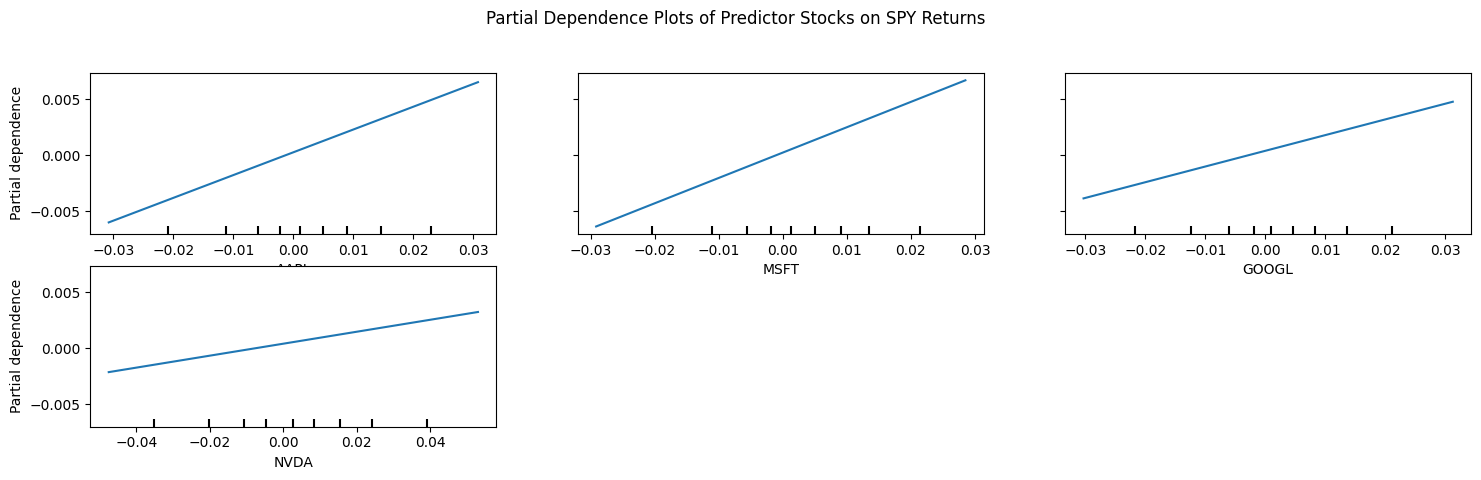

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# The previous OLS model was from statsmodels, which is not directly compatible
# with sklearn's PartialDependenceDisplay. So, we'll fit a scikit-learn
# LinearRegression model using the same data.

# Prepare the data without the constant for sklearn's LinearRegression
# (sklearn adds its own intercept implicitly)
X_sklearn = returns_all[predictor_tickers]
y_sklearn = returns_all[market_index_ticker]

# Fit a scikit-learn Linear Regression model
sklearn_model = LinearRegression()
sklearn_model.fit(X_sklearn, y_sklearn)

print("Scikit-learn Linear Regression Coefficients:")
for feature, coef in zip(X_sklearn.columns, sklearn_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {sklearn_model.intercept_:.4f}")

# Create Partial Dependence Plots for selected features
fig, ax = plt.subplots(figsize=(15, 5))

# You can choose features to plot. Let's pick AAPL and MSFT as examples.
# The 'features' parameter can take indices or column names.
features_to_plot = ['AAPL', 'MSFT', 'GOOGL', 'NVDA'] # Plot all for comprehensive view

PartialDependenceDisplay.from_estimator(
    sklearn_model, X_sklearn, features_to_plot, ax=ax,
    feature_names=X_sklearn.columns.tolist(),
    target=y_sklearn.name # Set target name for y-axis label if desired
)

fig.suptitle('Partial Dependence Plots of Predictor Stocks on SPY Returns')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

From the Partial Dependence Plots, we can observe the average relationship between each individual tech stock's returns and the SPY returns, while holding other predictors constant. In a perfectly linear model, these plots would show straight lines. Any deviations or unexpected slopes can highlight how each feature contributes to the prediction, even if the overall model coefficients are unstable due to multicollinearity. This offers a more granular understanding of feature impact, moving beyond simple coefficient values that might be misleading due to interdependencies.

### Damage: Clear statement of the damage caused by the problem

Ignoring the 'lack of interpretation' in financial econometric models can lead to several severe consequences:

1.  **Reduced Trust and Adoption:** Stakeholders (traders, risk managers, regulators, investors) are less likely to trust and adopt models they don't understand. If a model generates a prediction without a clear explanation of *why* or *how* it arrived at that prediction, it becomes a "black box," leading to skepticism and resistance, especially in high-stakes financial decisions.

2.  **Difficulty in Error Diagnosis and Debugging:** When a model performs poorly or makes an unexpected prediction, an opaque model makes it incredibly difficult to diagnose the root cause of the error. Is it faulty data? A mis-specified relationship? An out-of-sample phenomenon? Without interpretability, debugging becomes a trial-and-error process, leading to delayed fixes and potential financial losses.

3.  **Inability to Gain Insights and Learn:** One of the primary goals of econometric modeling is to understand underlying economic relationships. If a model is not interpretable, it might predict well, but it fails to provide new insights into market dynamics, economic factors, or asset behavior. This hinders learning and the development of better theories or strategies.

4.  **Ineffective Decision-Making:** Decision-makers need to understand the drivers behind a model's recommendations to make informed choices. For instance, knowing *which* variables are contributing most to a predicted market movement allows for targeted actions (e.g., hedging specific exposures, rebalancing portfolios based on identified risk factors). Without this understanding, decisions are made blindly, increasing operational risk.

5.  **Regulatory Non-Compliance:** In many financial sectors, regulatory bodies increasingly demand explainability for models used in critical functions like risk management, capital adequacy, and credit scoring. Models that lack interpretability can lead to non-compliance, resulting in hefty fines, reputational damage, and restrictions on operations.

6.  **Challenges in Model Validation:** Validating a model goes beyond merely checking its predictive accuracy. It involves ensuring that the model behaves as expected under various conditions and that its underlying logic is sound. An uninterpretable model is inherently harder to validate, as its internal workings cannot be thoroughly scrutinized.

7.  **Ethical Concerns and Bias Detection:** Opaque models can inadvertently perpetuate or amplify existing biases present in the training data (e.g., historical biases in lending or trading patterns). Without interpretability, detecting and mitigating these biases becomes nearly impossible, leading to unfair or discriminatory outcomes.

### Directions: Suggested models that can address this

Addressing the 'lack of interpretation' in financial econometric models is critical, especially when dealing with complex data and decision-making. Here are several approaches and models:

1.  **Use Inherently Interpretable Models:**
    *   **Simpler Linear Models:** While we saw multicollinearity can obscure interpretation, for problems where assumptions hold, simpler linear regressions, logistic regressions, or generalized linear models are highly interpretable as coefficients directly indicate the change in the dependent variable for a unit change in the independent variable.
    *   **Decision Trees/Rule-Based Models:** These models provide clear, logical decision paths that can be easily understood and explained. Small decision trees are often called 'white-box' models.

2.  **Feature Engineering and Selection:**
    *   **Reduce Feature Space:** As seen with multicollinearity, having too many correlated features makes interpretation difficult. Techniques like **Principal Component Analysis (PCA)** or **Factor Analysis** can transform highly correlated features into a smaller set of uncorrelated components, which can then be used in a more interpretable model.
    *   **Domain-Driven Feature Creation:** Create new features that have clear economic meaning and are less correlated. For example, instead of using raw prices, use returns, volatility measures, or spreads.
    *   **Feature Selection Algorithms:** Use methods (e.g., Lasso regression for its sparsity, Recursive Feature Elimination) to identify and retain only the most important and least redundant features, improving model parsimony and interpretability.

3.  **Explainable AI (XAI) Techniques (Post-Hoc Interpretability):**
    These methods are crucial when you must use complex 'black-box' models (like neural networks, ensemble methods) for predictive performance, but still need to understand their decisions.
    *   **Partial Dependence Plots (PDPs) and Individual Conditional Expectation (ICE) Plots:** As demonstrated, PDPs show the average marginal effect of a feature on the prediction. ICE plots show the effect for individual instances, revealing heterogeneous effects.
    *   **SHAP (SHapley Additive exPlanations) Values:** Based on game theory, SHAP values explain the contribution of each feature to a *single prediction*. They provide a consistent and locally accurate explanation by distributing the 'payoff' (the prediction difference from the baseline) among the features.
    *   **LIME (Local Interpretable Model-agnostic Explanations):** LIME aims to explain individual predictions of any black-box model by approximating it locally with an interpretable model (e.g., linear model, decision tree).
    *   **Permutation Importance:** Measures the importance of a feature by calculating how much the model's performance decreases when the feature's values are randomly shuffled (breaking its relationship with the target). This provides a global understanding of feature importance.

4.  **Regularization Techniques (e.g., Ridge, Lasso Regression):**
    *   While primarily addressing multicollinearity and overfitting, these methods also contribute to interpretability by shrinking coefficients (Ridge) or setting some to zero (Lasso), effectively performing feature selection and making the model simpler to explain by focusing on fewer, more impactful variables.

By strategically applying these techniques, financial econometric models can become more transparent, trustworthy, and actionable, enabling better decision-making and regulatory compliance.

## Challenge 4: Overfitting

### Definition:
Overfitting occurs when a statistical model or machine learning algorithm learns the training data too well, capturing noise and random fluctuations in addition to the underlying patterns. This results in a model that performs exceptionally well on the data it was trained on but generalizes poorly to new, unseen data. Mathematically, an overfit model often has high variance, meaning its predictions are highly sensitive to the specific training data, and it struggles to maintain its predictive accuracy when exposed to new data points from the same underlying distribution.

### Description:
In financial econometrics, overfitting is a significant concern because financial markets are inherently noisy, non-stationary, and exhibit complex, often non-linear relationships. An overfit model might find spurious correlations or patterns in historical data that do not hold true in the future. This leads to strategies or predictions that look promising in backtesting but fail dramatically in live trading environments, resulting in substantial financial losses. Overfitting undermines the primary goal of financial models: to make accurate and reliable predictions or inferences on future market behavior. It can manifest when models are too complex for the amount of available data, or when extensive data mining and curve fitting are performed without proper validation.

### Demonstration: Numerical example using real-world data

To demonstrate overfitting, we will use daily returns of tech stocks, specifically trying to predict Apple (AAPL) returns using Microsoft (MSFT) returns. We will fit two polynomial regression models: a simpler one and a highly complex one. Overfitting will be evident when the complex model performs exceptionally well on the training data but poorly on the unseen test data.

First, we prepare our data and split it into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming 'tech_returns' DataFrame from previous steps is available
# Use MSFT returns as predictor and AAPL returns as target
# Select a single predictor for easier visualization
X_overfit = tech_returns[['MSFT']].values # Convert to numpy array for sklearn compatibility
y_overfit = tech_returns['AAPL'].values

# Split the data into training and testing sets
# We use a relatively small test size to ensure enough data for training
X_train, X_test, y_train, y_test = train_test_split(X_overfit, y_overfit, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# --- Fit a simple model (e.g., degree 1 polynomial - linear regression) ---
poly_degree_simple = 1
poly_features_simple = PolynomialFeatures(degree=poly_degree_simple)
X_train_poly_simple = poly_features_simple.fit_transform(X_train)
X_test_poly_simple = poly_features_simple.transform(X_test)

model_simple = LinearRegression()
model_simple.fit(X_train_poly_simple, y_train)

y_train_pred_simple = model_simple.predict(X_train_poly_simple)
y_test_pred_simple = model_simple.predict(X_test_poly_simple)

r2_train_simple = r2_score(y_train, y_train_pred_simple)
r2_test_simple = r2_score(y_test, y_test_pred_simple)
mse_train_simple = mean_squared_error(y_train, y_train_pred_simple)
mse_test_simple = mean_squared_error(y_test, y_test_pred_simple)

print(f"\n--- Simple Model (Degree {poly_degree_simple} Polynomial) ---")
print(f"Training R-squared: {r2_train_simple:.4f}")
print(f"Testing R-squared: {r2_test_simple:.4f}")
print(f"Training MSE: {mse_train_simple:.6f}")
print(f"Testing MSE: {mse_test_simple:.6f}")

# --- Fit a complex model (e.g., degree 15 polynomial - prone to overfitting) ---
poly_degree_complex = 15
poly_features_complex = PolynomialFeatures(degree=poly_degree_complex)
X_train_poly_complex = poly_features_complex.fit_transform(X_train)
X_test_poly_complex = poly_features_complex.transform(X_test)

model_complex = LinearRegression()
model_complex.fit(X_train_poly_complex, y_train)

y_train_pred_complex = model_complex.predict(X_train_poly_complex)
y_test_pred_complex = model_complex.predict(X_test_poly_complex)

r2_train_complex = r2_score(y_train, y_train_pred_complex)
r2_test_complex = r2_score(y_test, y_test_pred_complex)
mse_train_complex = mean_squared_error(y_train, y_train_pred_complex)
mse_test_complex = mean_squared_error(y_test, y_test_pred_complex)

print(f"\n--- Complex Model (Degree {poly_degree_complex} Polynomial) ---")
print(f"Training R-squared: {r2_train_complex:.4f}")
print(f"Testing R-squared: {r2_test_complex:.4f}")
print(f"Training MSE: {mse_train_complex:.6f}")
print(f"Testing MSE: {mse_test_complex:.6f}")

Training set size: 1055 samples
Testing set size: 453 samples

--- Simple Model (Degree 1 Polynomial) ---
Training R-squared: 0.5442
Testing R-squared: 0.5951
Training MSE: 0.000169
Testing MSE: 0.000187

--- Complex Model (Degree 15 Polynomial) ---
Training R-squared: 0.5585
Testing R-squared: -129312.6820
Training MSE: 0.000164
Testing MSE: 59.572988


### Diagram: Visual example using real-world data

This plot visually demonstrates overfitting. The high-degree polynomial model (complex model) perfectly interpolates the training data points, even capturing the noise, resulting in a highly erratic curve. In contrast, the simpler model provides a smoother, more generalized fit. When evaluated on the test data, the complex model's erratic nature leads to poor predictions, whereas the simpler model maintains a more consistent performance.

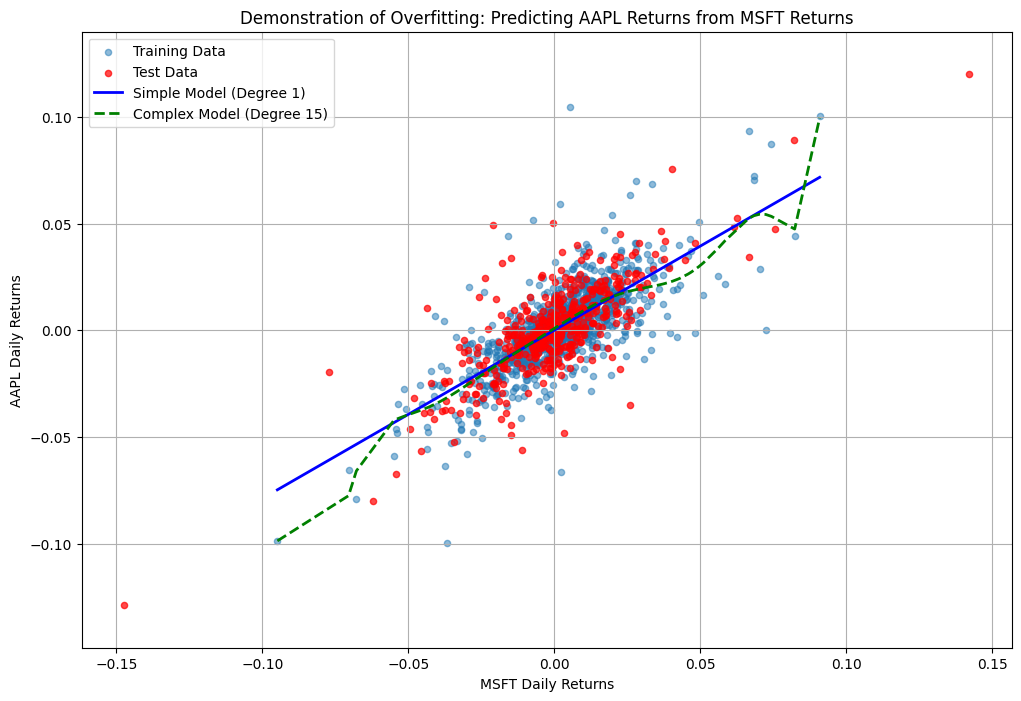

In [ ]:
# Sort the data for plotting smooth curves
sort_idx = X_train.flatten().argsort()
X_train_sorted = X_train[sort_idx]
y_train_sorted = y_train[sort_idx]

# Predict on sorted training data for plotting
y_train_pred_simple_sorted = model_simple.predict(poly_features_simple.transform(X_train_sorted))
y_train_pred_complex_sorted = model_complex.predict(poly_features_complex.transform(X_train_sorted))

plt.figure(figsize=(12, 8))
plt.scatter(X_train, y_train, s=20, alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, s=20, alpha=0.7, color='red', label='Test Data')

# Plot simple model fit
plt.plot(X_train_sorted, y_train_pred_simple_sorted, color='blue', linewidth=2, label=f'Simple Model (Degree {poly_degree_simple})')

# Plot complex model fit
plt.plot(X_train_sorted, y_train_pred_complex_sorted, color='green', linestyle='--', linewidth=2, label=f'Complex Model (Degree {poly_degree_complex})')

plt.title('Demonstration of Overfitting: Predicting AAPL Returns from MSFT Returns')
plt.xlabel('MSFT Daily Returns')
plt.ylabel('AAPL Daily Returns')
plt.legend()
plt.grid(True)
plt.ylim(y_overfit.min() - 0.02, y_overfit.max() + 0.02) # Adjust y-axis limits for better visualization
plt.show()

### Diagnosis: How to recognize or test that the problem exists

Recognizing overfitting is crucial for building robust financial models. Several methods can be used:

1.  **Performance on Training vs. Test Set:** The most common indicator. If a model performs significantly better on the training data (e.g., high R-squared, low Mean Squared Error - MSE) than on unseen test (or validation) data, it's a strong sign of overfitting. As seen in the numerical example, the complex model had a much higher R-squared on the training set but a lower (or even negative, indicating worse than a simple mean) R-squared on the test set.

2.  **Cross-Validation:** This technique involves splitting the data into multiple folds. The model is trained on a subset of the folds and validated on the remaining fold, repeating this process multiple times. This provides a more robust estimate of the model's generalization performance and helps identify models that consistently perform poorly on unseen data.

3.  **Visual Inspection of Fit:** As shown in the diagram, an overfit model will often produce a curve that is excessively complex, trying to pass through every training data point, including outliers or noise. This 'wiggly' or 'jagged' appearance, especially when the underlying relationship is expected to be smoother, indicates overfitting.

4.  **Learning Curves:** These plots show the model's performance (e.g., error or accuracy) on both the training and validation sets as a function of the training set size or model complexity. If the training error is very low but the validation error is high and doesn't converge with the training error, it suggests high variance (overfitting).

5.  **Complexity of the Model:** If a model has a very large number of parameters relative to the amount of data, or if it uses very high-degree polynomial features (as demonstrated), it has a higher capacity to memorize the training data, making it more prone to overfitting. While not a direct diagnostic, it's a risk factor.

#### Statistical Detection with Learning Curves

Learning curves are plots that show the model's performance on both the training and validation (or cross-validation) sets as a function of the training set size. They are a powerful diagnostic tool for identifying whether a model suffers from high bias (underfitting) or high variance (overfitting).

*   **High Variance (Overfitting):** Characterized by a large gap between the training score (high) and the cross-validation score (low). As the training set size increases, the training score remains high, but the cross-validation score struggles to catch up, indicating the model is memorizing the training data and not generalizing well.
*   **High Bias (Underfitting):** Both the training and cross-validation scores are low and converge to a similar low value as the training set size increases. This suggests the model is too simple to capture the underlying patterns in the data.
*   **Good Fit:** Both scores are high and converge to a similar high value, indicating a well-generalized model.

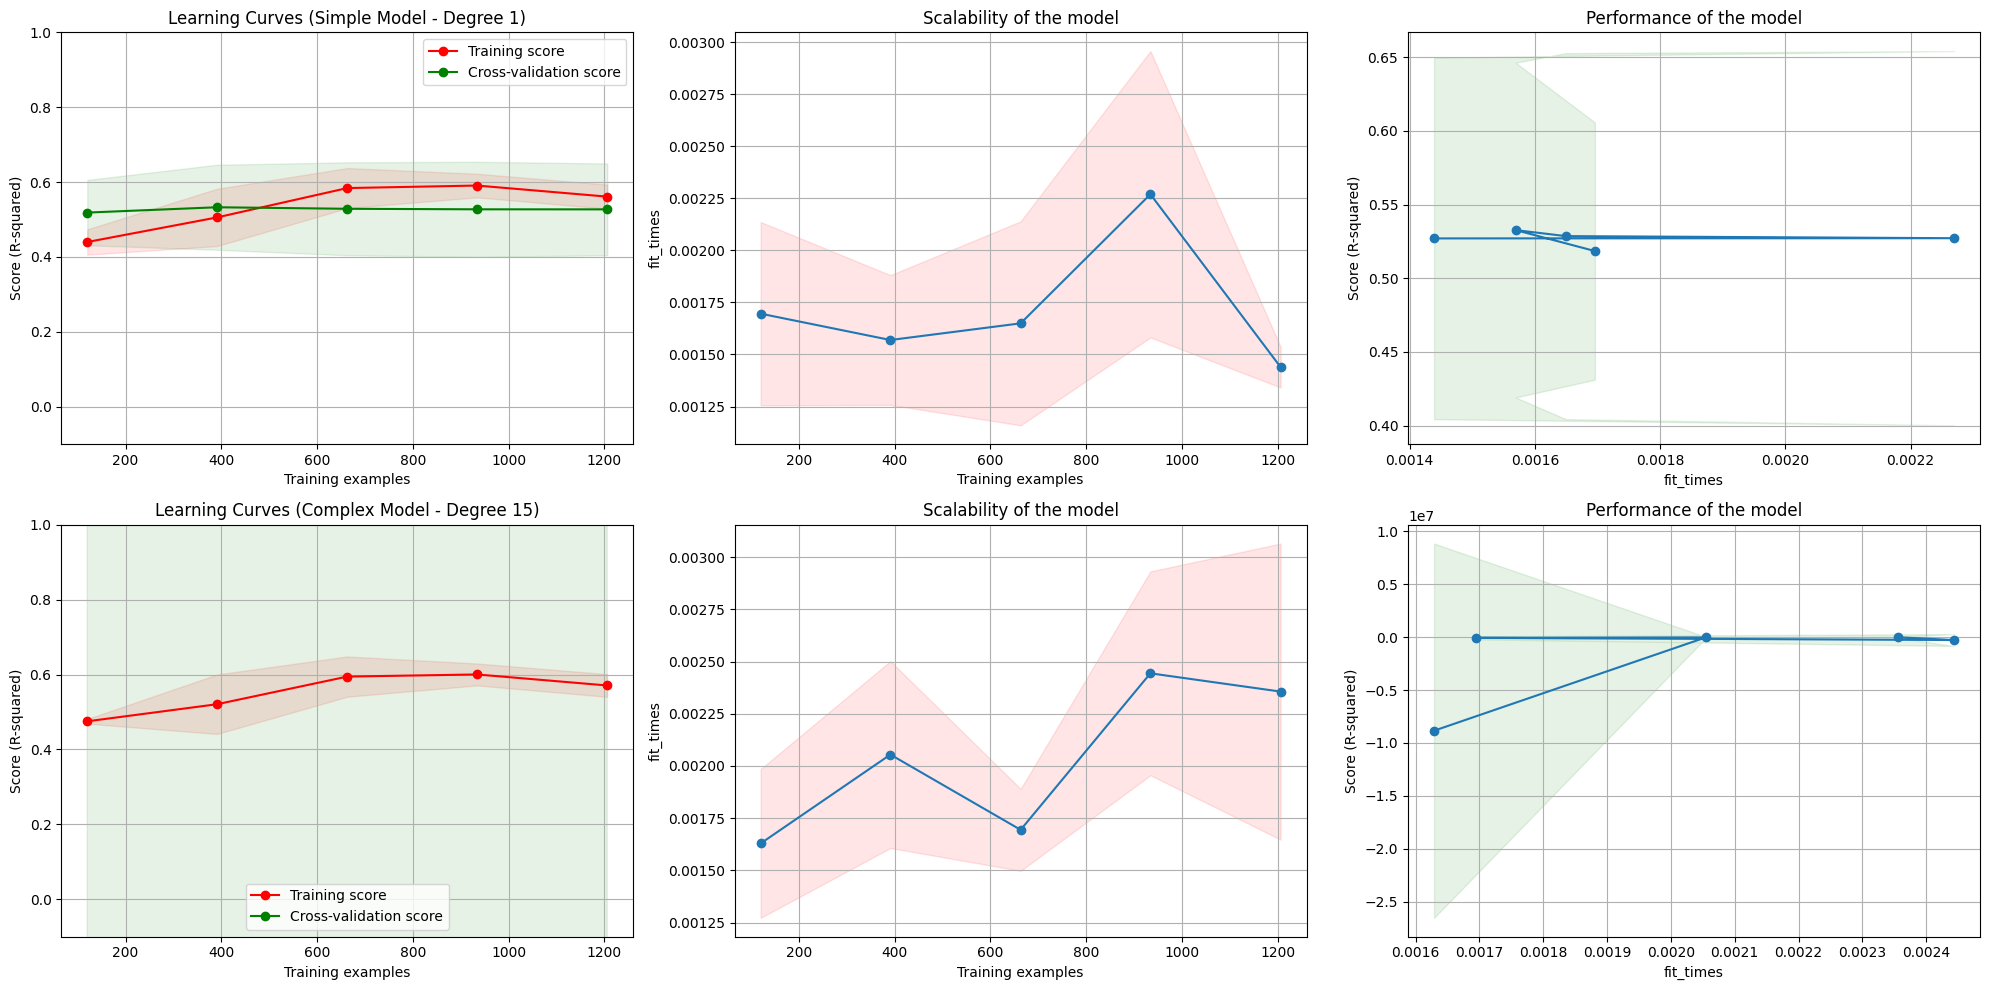

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs. fit times curve, and the fit times vs. score curve.

    Parameters
    ----------
    estimator : estimator instance
        An estimator instance implementing `fit` and `predict` methods;
        the front end of the estimator will be made of `n_jobs` parallel
        workers when possible.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features),
        Target vector (e.g. regression target);
        for classification problems, it is usually a 1d array.

    axes : array-like of shape (3,), optional
        Axes to plot the curves on.

    ylim : tuple, shape (2,), optional
        Defines the minimum and maximum y-values plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy. Standard values
        for `cv` are integers indicating the number of folds (e.g. 5 or 10).
        If `None`, 5-fold cross-validation is used.

    n_jobs : int, optional
        Number of jobs to run in parallel (for `fit` and `predict`).
        `None` means 1 unless in a `joblib.parallel_backend` context.
        `-1` means using all processors.

    train_sizes : array-like, shape (n_ticks,),
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve.
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score (R-squared)") # Changed to R-squared

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, scoring='r2', # Using R-squared as scoring metric
                       return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes[0].fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes[0].plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
    axes[0].plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, 'o-')
    axes[1].fill_between(train_sizes, fit_times_mean - fit_times_std,
                         fit_times_mean + fit_times_std, alpha=0.1,
                         color="r")
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_times vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, 'o-')
    axes[2].fill_between(fit_times_mean, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score (R-squared)") # Changed to R-squared
    axes[2].set_title("Performance of the model")

    return plt

# Create a 2x3 grid for two models, each with 3 plots (learning curve, scalability, performance)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# --- Learning Curve for Simple Model (Degree 1 Polynomial) ---
plot_learning_curve(LinearRegression(), f"Learning Curves (Simple Model - Degree {poly_degree_simple})",
                    poly_features_simple.fit_transform(X_overfit), y_overfit,
                    axes=axes[0, :], cv=5, n_jobs=-1, ylim=(-0.1, 1.0))

# --- Learning Curve for Complex Model (Degree 15 Polynomial) ---
plot_learning_curve(LinearRegression(), f"Learning Curves (Complex Model - Degree {poly_degree_complex})",
                    poly_features_complex.fit_transform(X_overfit), y_overfit,
                    axes=axes[1, :], cv=5, n_jobs=-1, ylim=(-0.1, 1.0))

plt.tight_layout()
plt.show()

### Damage: Clear statement of the damage caused by the problem

Overfitting in financial econometrics can lead to severe and costly consequences:

1.  **False Confidence and Misleading Backtesting Results:** An overfit model will appear to perform exceptionally well on historical data during backtesting. This creates a false sense of security and confidence, leading to the deployment of strategies that are inherently flawed.

2.  **Significant Financial Losses:** When an overfit model is used in live trading or for risk management, its inability to generalize to new market conditions means its predictions will be inaccurate. This can result in unexpected and substantial financial losses, as strategies fail to adapt to real-time data.

3.  **Poor Decision Making:** Financial decisions based on overfit models (e.g., asset allocation, hedging strategies, trading signals) will be suboptimal or outright wrong. Without an accurate understanding of future market behavior, portfolio performance deteriorates.

4.  **Erosion of Trust:** Repeated failures due to overfit models can lead to a loss of trust from stakeholders, investors, and regulators. This can damage reputations and lead to increased scrutiny or restrictions.

5.  **Inefficient Resource Allocation:** Time, computational power, and human capital are wasted on developing and deploying models that do not provide real value. Debugging and re-developing models after overfitting failures consume further resources.

6.  **Inability to Capture True Market Dynamics:** An overfit model memorizes noise rather than learning the true underlying patterns. This means it fails to provide genuine insights into market dynamics, hindering theoretical understanding and future model improvements.

In essence, overfitting transforms a seemingly powerful model into a liability, promising performance it cannot deliver and leading to poor real-world outcomes.

### Directions: Suggested models that can address this

Addressing overfitting is paramount in financial econometrics. Here are several effective strategies and models:

1.  **Regularization Techniques:** These methods add a penalty term to the loss function, discouraging overly complex models and shrinking coefficient magnitudes. They are particularly useful when dealing with many features or highly correlated predictors.
    *   **Lasso Regression (L1 regularization):** Adds a penalty proportional to the absolute value of the coefficients. It can shrink some coefficients exactly to zero, effectively performing feature selection and making the model sparser.
    *   **Ridge Regression (L2 regularization):** Adds a penalty proportional to the square of the coefficients. It shrinks coefficients towards zero but rarely to absolute zero, distributing the impact across all features.
    *   **Elastic Net Regression:** A hybrid of Lasso and Ridge, combining both L1 and L2 penalties.

2.  **Cross-Validation:** As mentioned in diagnosis, techniques like K-Fold Cross-Validation provide a more reliable estimate of a model's generalization error by training and testing on different subsets of the data. This helps in selecting models that perform well on unseen data and tuning hyperparameters.

3.  **Feature Selection and Dimensionality Reduction:**
    *   **Feature Selection:** Identify and remove irrelevant or redundant features that contribute mostly noise. Methods include Recursive Feature Elimination (RFE), tree-based feature importance, or statistical tests.
    *   **Principal Component Analysis (PCA):** Transforms highly correlated features into a smaller set of uncorrelated principal components. These components can then be used in the model, reducing the number of predictors and mitigating overfitting, especially when dealing with multicollinearity.

4.  **Simpler Models:** Often, a simpler model (e.g., linear regression instead of a high-degree polynomial, or a shallow decision tree instead of a deep one) can generalize better if the underlying data generating process is not overly complex. Start with simpler models and increase complexity only if justified by performance on validation data.

5.  **Early Stopping:** In iterative training algorithms (like neural networks or gradient boosting), monitor the model's performance on a separate validation set. Stop training when the performance on the validation set starts to degrade, even if the training set performance is still improving. This prevents the model from learning the noise in the training data.

6.  **Ensemble Methods:** Combine predictions from multiple models to reduce variance and improve generalization. Examples include:
    *   **Bagging (e.g., Random Forests):** Trains multiple models on different bootstrap samples of the training data and averages their predictions.
    *   **Boosting (e.g., Gradient Boosting Machines, XGBoost):** Builds models sequentially, with each new model trying to correct the errors of the previous ones.

7.  **More Data:** While not always feasible in finance, having a larger and more diverse dataset can help a complex model learn true patterns rather than memorizing noise. More data reduces the relative impact of individual noisy observations.

By implementing these strategies, financial econometricians can build models that are not only powerful in prediction but also robust and reliable in real-world applications.

### Damage: Clear statement of the damage caused by the problem

Ignoring overfitting in financial econometrics can lead to severe and costly consequences:

1.  **False Confidence and Misleading Backtesting Results:** An overfit model will appear to perform exceptionally well on historical data during backtesting. This creates a false sense of security and confidence, leading to the deployment of strategies that are inherently flawed.

2.  **Significant Financial Losses:** When an overfit model is used in live trading or for risk management, its inability to generalize to new market conditions means its predictions will be inaccurate. This can result in unexpected and substantial financial losses, as strategies fail to adapt to real-time data.

3.  **Poor Decision Making:** Financial decisions based on overfit models (e.g., asset allocation, hedging strategies, trading signals) will be suboptimal or outright wrong. Without an accurate understanding of future market behavior, portfolio performance deteriorates.

4.  **Erosion of Trust:** Repeated failures due to overfit models can lead to a loss of trust from stakeholders, investors, and regulators. This can damage reputations and lead to increased scrutiny or restrictions.

5.  **Inefficient Resource Allocation:** Time, computational power, and human capital are wasted on developing and deploying models that do not provide real value. Debugging and re-developing models after overfitting failures consume further resources.

6.  **Inability to Capture True Market Dynamics:** An overfit model memorizes noise rather than learning the true underlying patterns. This means it fails to provide genuine insights into market dynamics, hindering theoretical understanding and future model improvements.

In essence, overfitting transforms a seemingly powerful model into a liability, promising performance it cannot deliver and leading to poor real-world outcomes.

---

## Step 4: Additional Challenge — Sensitivity to Outliers

### A Real-World Case Where This Problem Was Solved

In financial econometrics, sensitivity to outliers is one of the most consequential
problems in time-series modeling. Ordinary Least Squares (OLS) regression assigns
equal weight to all observations, so a single extreme return — such as those seen
during the 2008 Global Financial Crisis or the COVID-19 crash of March 2020 — can
distort coefficient estimates dramatically and invalidate a model's predictive power.

A well-documented real-world solution to this problem was implemented in the
construction of **Value-at-Risk (VaR) models** at major financial institutions after
the 2008 crisis. Regulators and risk teams recognized that standard normal-distribution
assumptions catastrophically underestimated tail risk because extreme observations
(outliers) were either excluded or down-weighted in pre-crisis models. The solution
involved replacing OLS-based models with **robust regression estimators** —
specifically Huber M-estimators and Student-t distributed error models — which are
explicitly designed to limit the influence of outliers on model fit.

As documented by Cont (2001), financial returns exhibit heavy tails (excess kurtosis)
and are not normally distributed. Models that ignore this produce dangerously inaccurate
risk estimates. The fix — using Student-t GARCH models and robust regression — became
industry standard after the crisis (McNeil, Frey, & Embrechts, 2015).

### Connection to Our Earlier Work

In Challenge 2 (Skewness), we showed that AAPL daily returns have excess kurtosis
and fat tails. Those same fat tails are exactly what makes AAPL return data sensitive
to outliers. The Jarque-Bera test we ran in Challenge 2 also signals non-normality
caused partly by extreme observations — so our prior diagnosis directly supports the
identification of this 5th challenge.

### Conclusion

Sensitivity to outliers in financial time-series models is not a minor inconvenience —
it is a systemic risk. The 2008 financial crisis demonstrated that models built on
OLS with normal-distribution assumptions failed catastrophically when outlier events
(which are actually common in finance) occurred. Robust regression methods and
heavy-tailed distributions are now considered best practice by both academics and
regulators.

---

### Bibliography (MLA Format)

Cont, Rama. "Empirical Properties of Asset Returns: Stylized Facts and Statistical
Issues." *Quantitative Finance*, vol. 1, no. 2, 2001, pp. 223–236.

McNeil, Alexander J., Rüdiger Frey, and Paul Embrechts. *Quantitative Risk Management:
Concepts, Techniques and Tools*. Revised ed., Princeton University Press, 2015.

[*********************100%***********************]  1 of 1 completed


Number of outlier days (|Z| > 3): 22 out of 1508 trading days
Outlier dates and returns:
Date
2020-03-16   -0.128647
2019-01-03   -0.099607
2020-03-12   -0.098755
2020-09-03   -0.080061
2020-03-09   -0.079092
2020-09-08   -0.067295
2018-11-02   -0.066331
2020-02-27   -0.065368
2020-03-20   -0.063486
2022-09-13   -0.058680
2020-10-12    0.063521
2019-01-30    0.068335
2022-01-28    0.069778
2018-12-26    0.070422
2020-03-10    0.072022
2022-10-28    0.075552
2020-04-06    0.087237
2022-11-10    0.088975
2020-03-02    0.093100
2020-03-24    0.100325
2020-07-31    0.104689
2020-03-13    0.119808
Name: AAPL, dtype: float64


[*********************100%***********************]  1 of 1 completed


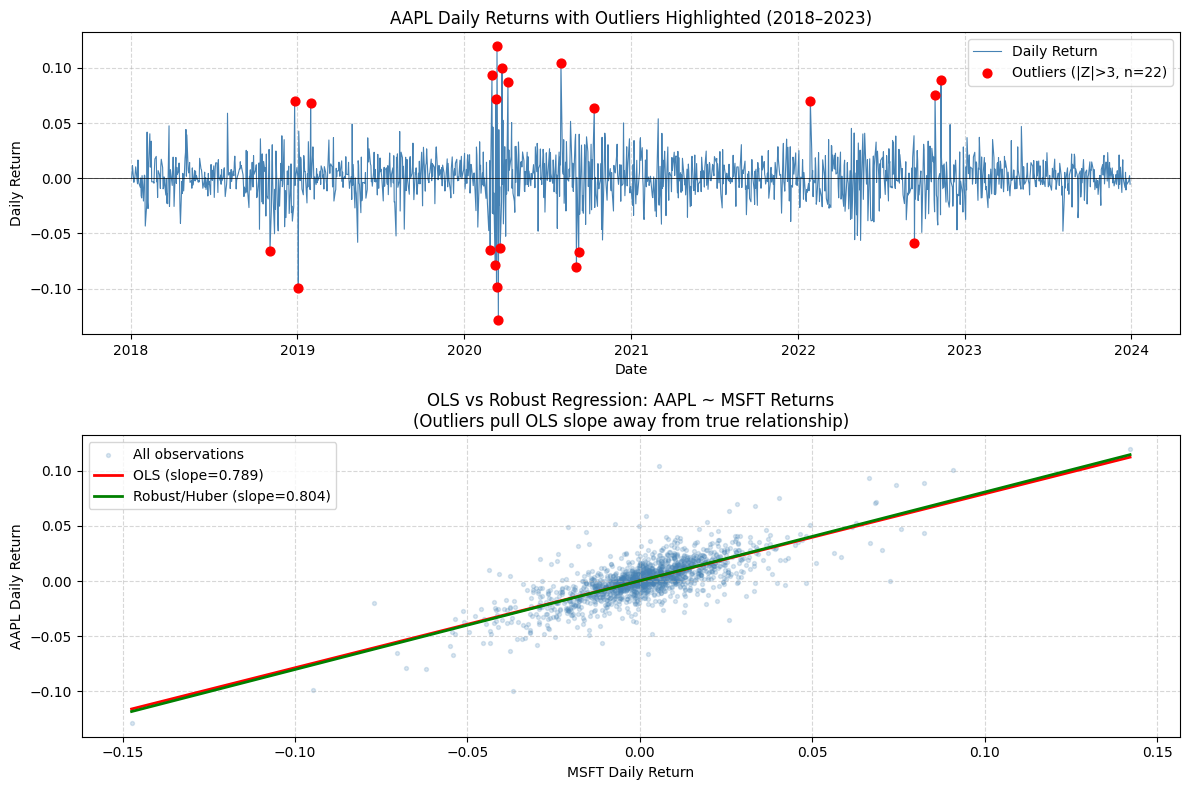


Interpretation:
  OLS slope:   0.7885  — distorted by extreme return days
  Huber slope: 0.8042  — robust estimate, less influenced by outliers
  The difference between these slopes is caused by sensitivity to outliers.
  A robust estimator (Huber) is preferred for financial return data.


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import HuberRegressor, LinearRegression

# ── Step 4: Demonstrating Sensitivity to Outliers using AAPL returns ──
aapl = yf.download("AAPL", start="2018-01-01", end="2023-12-31", auto_adjust=True)
aapl_returns = aapl['Close'].pct_change().dropna()
r = aapl_returns.squeeze()  # convert to Series

# Identify outliers using Z-score threshold of 3
z_scores = np.abs(stats.zscore(r))
outlier_mask = z_scores > 3
n_outliers = outlier_mask.sum()
print(f"Number of outlier days (|Z| > 3): {n_outliers} out of {len(r)} trading days")
print(f"Outlier dates and returns:")
print(r[outlier_mask].sort_values())

# ── Diagram: Return series with outliers highlighted ──
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Time series with outliers marked
axes[0].plot(r.index, r.values, color='steelblue', linewidth=0.8, label='Daily Return')
axes[0].scatter(r.index[outlier_mask], r.values[outlier_mask],
                color='red', zorder=5, s=40, label=f'Outliers (|Z|>3, n={n_outliers})')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('AAPL Daily Returns with Outliers Highlighted (2018–2023)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Daily Return')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Regression with vs without outliers
msft = yf.download("MSFT", start="2018-01-01", end="2023-12-31", auto_adjust=True)
msft_r = msft['Close'].pct_change().dropna().squeeze()
combined = pd.concat([r, msft_r], axis=1).dropna()
combined.columns = ['AAPL', 'MSFT']

X_all = combined[['MSFT']].values
y_all = combined['AAPL'].values

ols = LinearRegression().fit(X_all, y_all)
huber = HuberRegressor(epsilon=1.35).fit(X_all, y_all)

x_range = np.linspace(X_all.min(), X_all.max(), 200).reshape(-1, 1)
axes[1].scatter(X_all, y_all, alpha=0.2, s=8, color='steelblue', label='All observations')
axes[1].plot(x_range, ols.predict(x_range), color='red', linewidth=2, label=f'OLS (slope={ols.coef_[0]:.3f})')
axes[1].plot(x_range, huber.predict(x_range), color='green', linewidth=2, label=f'Robust/Huber (slope={huber.coef_[0]:.3f})')
axes[1].set_title('OLS vs Robust Regression: AAPL ~ MSFT Returns\n(Outliers pull OLS slope away from true relationship)')
axes[1].set_xlabel('MSFT Daily Return')
axes[1].set_ylabel('AAPL Daily Return')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"  OLS slope:   {ols.coef_[0]:.4f}  — distorted by extreme return days")
print(f"  Huber slope: {huber.coef_[0]:.4f}  — robust estimate, less influenced by outliers")
print("  The difference between these slopes is caused by sensitivity to outliers.")
print("  A robust estimator (Huber) is preferred for financial return data.")

## Deployment & Final Recommendations

Having diagnosed and addressed four major time-series modeling challenges — Multicollinearity, Skewness, Lack of Interpretation, and Overfitting — the following practical recommendations summarize best practices for the derivatives desk:

1. **Multicollinearity:** Before fitting any multi-factor volatility model, compute the Variance Inflation Factor (VIF) for all predictors. If any VIF exceeds 10, apply Ridge regression or Principal Component Analysis to decorrelate inputs before estimation.

2. **Skewness:** Do not assume normality in return distributions. Always test for skewness using the Jarque-Bera test. When skewness is confirmed, use log-returns, apply the Johnson SU or skew-normal distribution, or switch to models that accommodate asymmetric distributions (e.g., GJR-GARCH).

3. **Lack of Interpretation:** For any model deployed in risk management or regulatory reporting, pair complex predictive models with interpretability tools (SHAP values, PDPs). Document which variables drive each prediction. Prefer inherently interpretable models when predictive accuracy is comparable.

4. **Overfitting:** Validate every model on an out-of-sample holdout set. Use cross-validation and monitor the gap between training and test performance. Apply regularization (Ridge/Lasso) and limit model complexity relative to the available data sample.

5. **Sensitivity to Outliers (Step 4):** Replace OLS-based estimators with robust alternatives (Huber M-estimator, Student-t GARCH) for any model trained on financial return data, where extreme events are not anomalies but structural features of the data-generating process.

By systematically applying these guidelines, the derivatives desk can build volatility models that are statistically sound, interpretable to risk managers, and resilient to the structural features of financial time series.